### Traditional classifier 

### cleaning strategy use median as the data is skewed so mean would have negative effect on missing values
- Keep missing panels as flags and impute inside the ML pipeline: `SimpleImputer(strategy="median")`
- Use `class_weight="balanced"` because of the class imbalance

In [17]:
import pandas as pd
import numpy as np

# one row per encounter (lab panel), created by src/data/prepare_data.py
df = pd.read_csv("../data/processed/lab_panels.csv")

print(df.shape)
print(df.columns.tolist())

(987, 24)
['encounter', 'patient', 'date', 'age', 'gender', 'ALT', 'Calcium', 'Carbon Dioxide', 'Chloride', 'Erythrocytes', 'Ferritin', 'Glucose', 'HbA1c', 'Hematocrit', 'Hemoglobin', 'Leukocytes', 'MCV', 'Platelets', 'Potassium', 'Sodium', 'TSH', 'Urea Nitrogen', 'abnormal_count', 'has_abnormal']


In [18]:
# Missing lab values mean "not ordered in this panel", so keep that information as flags
df["hba1c_missing"] = df["HbA1c"].isna().astype(int)
df["cbc_missing"] = df["Hemoglobin"].isna().astype(int)

In [19]:
# Ferritin and TSH are left out: measured in < 1 % of panels (see exploration)
numeric_features = [
    "age",
    "Glucose",
    "Urea Nitrogen",
    "Sodium",
    "Potassium",
    "Chloride",
    "Calcium",
    "Carbon Dioxide",
    "HbA1c",
    "Hemoglobin",
    "Hematocrit",
    "Leukocytes",
    "Platelets",
    "Erythrocytes",
    "MCV",
    "ALT",
]

categorical_features = [
    "gender",
]

binary_flag_features = ["hba1c_missing", "cbc_missing"]

feature_cols = numeric_features + categorical_features + binary_flag_features

X = df[feature_cols].copy()
y = df["has_abnormal"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts(normalize=True))

X shape: (987, 19)
y shape: (987,)
has_abnormal
1    0.871327
0    0.128673
Name: proportion, dtype: float64


In [20]:
from sklearn.model_selection import StratifiedGroupKFold

# One patient has many encounters, so the split is made per patient (no patient in both sets)
# while keeping the class ratio similar: one fold of 5 = ~20 % test
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=df["patient"]))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

assert not set(df["patient"].iloc[train_idx]) & set(df["patient"].iloc[test_idx])

print("Training:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Training: (766, 19)
Test: (221, 19)
has_abnormal
1    691
0     75
Name: count, dtype: int64
has_abnormal
1    169
0     52
Name: count, dtype: int64


In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_imputer = SimpleImputer(strategy="median")

X_train_num = num_imputer.fit_transform(X_train[numeric_features])
X_test_num = num_imputer.transform(X_test[numeric_features])

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)

In [22]:
from sklearn.preprocessing import OneHotEncoder

categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat = categorical_imputer.fit_transform(X_train[categorical_features])
X_test_cat = categorical_imputer.transform(X_test[categorical_features])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)

In [23]:
from numpy import hstack


X_train_flags = X_train[binary_flag_features].values
X_test_flags = X_test[binary_flag_features].values

X_train_processed = hstack([X_train_num, X_train_cat, X_train_flags])
X_test_processed = hstack([X_test_num, X_test_cat, X_test_flags])

processed_feature_names = (
    numeric_features + encoder.get_feature_names_out(categorical_features).tolist() + binary_flag_features
)

print("Training data:", X_train_processed.shape)
print("Test data:", X_test_processed.shape)

Training data: (766, 20)
Test data: (221, 20)


In [24]:
from sklearn.metrics import accuracy_score

majority_class = y_train.mode()[0]
y_baseline = np.full(len(y_test), majority_class)

baseline_accuracy = accuracy_score(y_test, y_baseline)
print("Majority class:", majority_class)
print("Baseline accuracy:", baseline_accuracy)

Majority class: 1
Baseline accuracy: 0.7647058823529411


In [25]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # up-weights the rare normal class during training
)

logreg.fit(X_train_processed, y_train)

y_pred = logreg.predict(X_test_processed)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test.iloc[:20].values)

Predicted: [0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0]
Actual:    [0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1]


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 score :", f1)

# abnormal is the majority class here, so also look at the rare normal class
print()
print(classification_report(y_test, y_pred, target_names=["normal", "abnormal"]))

Accuracy : 0.6787330316742082
Precision: 1.0
Recall   : 0.5798816568047337
F1 score : 0.7340823970037453

              precision    recall  f1-score   support

      normal       0.42      1.00      0.59        52
    abnormal       1.00      0.58      0.73       169

    accuracy                           0.68       221
   macro avg       0.71      0.79      0.66       221
weighted avg       0.86      0.68      0.70       221



[[52  0]
 [71 98]]


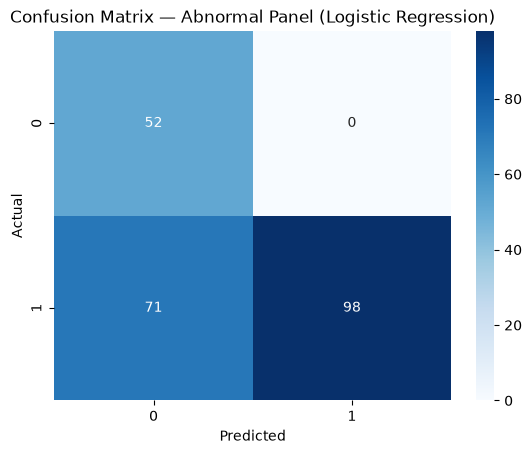

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Abnormal Panel (Logistic Regression)")
plt.show()

In [28]:
coefficients = pd.Series(logreg.coef_[0], index=processed_feature_names).sort_values()

display(coefficients.to_frame("coefficient"))

,coefficient
hba1c_missing,-3.781558
Carbon Dioxide,-0.955333
Hematocrit,-0.490998
gender_M,-0.236197
Hemoglobin,-0.206289
MCV,-0.198443
Sodium,-0.108692
ALT,-0.045475
age,-0.042946
Platelets,-0.026408


In [29]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)

tree.fit(X_train_processed, y_train)
y_tree_pred = tree.predict(X_test_processed)

In [30]:
tree_accuracy = accuracy_score(y_test, y_tree_pred)
tree_precision = precision_score(y_test, y_tree_pred)
tree_recall = recall_score(y_test, y_tree_pred)
tree_f1 = f1_score(y_test, y_tree_pred)

print("Decision Tree")
print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1       :", tree_f1)

print()
print(classification_report(y_test, y_tree_pred, target_names=["normal", "abnormal"]))

Decision Tree
Accuracy : 0.8914027149321267
Precision: 1.0
Recall   : 0.8579881656804734
F1       : 0.9235668789808917

              precision    recall  f1-score   support

      normal       0.68      1.00      0.81        52
    abnormal       1.00      0.86      0.92       169

    accuracy                           0.89       221
   macro avg       0.84      0.93      0.87       221
weighted avg       0.93      0.89      0.90       221



[[ 52   0]
 [ 24 145]]


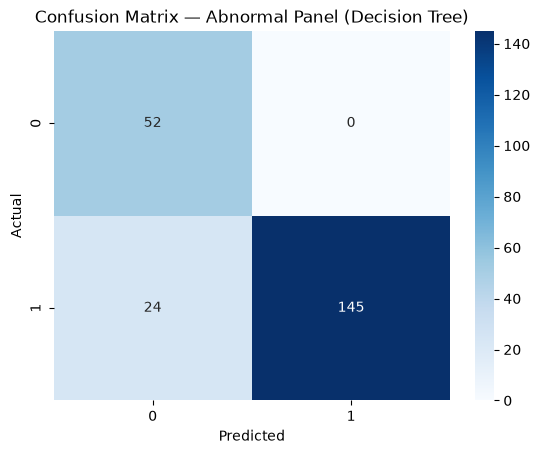

In [31]:
cm = confusion_matrix(y_test, y_tree_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Abnormal Panel (Decision Tree)")
plt.show()

In [32]:
from sklearn.tree import export_text

# thresholds are in standardized units (features were scaled)
print(export_text(tree, feature_names=processed_feature_names))

|--- hba1c_missing <= 0.50
|   |--- age <= 0.56
|   |   |--- HbA1c <= -2.21
|   |   |   |--- class: 1
|   |   |--- HbA1c >  -2.21
|   |   |   |--- class: 1
|   |--- age >  0.56
|   |   |--- Chloride <= -0.53
|   |   |   |--- Chloride <= -0.81
|   |   |   |   |--- class: 1
|   |   |   |--- Chloride >  -0.81
|   |   |   |   |--- class: 0
|   |   |--- Chloride >  -0.53
|   |   |   |--- gender_F <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- gender_F >  0.50
|   |   |   |   |--- class: 1
|--- hba1c_missing >  0.50
|   |--- Chloride <= 0.04
|   |   |--- Carbon Dioxide <= -0.64
|   |   |   |--- class: 1
|   |   |--- Carbon Dioxide >  -0.64
|   |   |   |--- Hemoglobin <= -2.13
|   |   |   |   |--- class: 1
|   |   |   |--- Hemoglobin >  -2.13
|   |   |   |   |--- class: 0
|   |--- Chloride >  0.04
|   |   |--- class: 1



In [33]:
comparison = pd.DataFrame(
    {
        "Model": ["Baseline", "Logistic Regression", "Decision Tree"],
        "Accuracy": [baseline_accuracy, accuracy, tree_accuracy],
        "Precision": [np.nan, precision, tree_precision],
        "Recall": [np.nan, recall, tree_recall],
        "F1": [np.nan, f1, tree_f1],
        "Recall (normal)": [
            0.0,
            recall_score(y_test, y_pred, pos_label=0),
            recall_score(y_test, y_tree_pred, pos_label=0),
        ],
    }
)

display(comparison)

,Model,Accuracy,Precision,Recall,F1,Recall (normal)
0,Baseline,0.764706,NaN,NaN,NaN,0.0
1,Logistic Regression,0.678733,1.0,0.579882,0.734082,1.0
2,Decision Tree,0.891403,1.0,0.857988,0.923567,1.0


### Results

- Test set: 221 panels (169 abnormal, 52 normal), no patient shared with the training set.
- The Decision Tree beats the majority baseline (0.89 vs 0.76 accuracy); Logistic Regression does not (0.68).
- Both models find all 52 normal panels and never call a normal panel abnormal (precision 1.0),
  but they call abnormal panels normal: Logistic Regression 71 of 169, Decision Tree 24 of 169.
- The label is a deterministic rule (value outside a reference range), but the models only approximate it:
  Logistic Regression cannot represent a two-sided range (`Low` and `High` are both abnormal),
  and a depth-4 tree has room for only a few of the thresholds.
- The split is per patient and a few patients have very many encounters, so the class ratio differs
  between train (10 % normal) and test (24 % normal) and the numbers depend on which patients land in the test set.